# Customer Churn Prediction — No-Churn Telecom
**Client:** No-Churn Telecom | **Category:** Telecom – Churn Rate ML

### Project Goals
1. Understand variables influencing customers to migrate (churn)
2. Create Churn Risk Scores to drive retention campaigns
3. Introduce `CHURN_FLAG` (YES=1 / NO=0) for targeted email campaigns

---
## 1. Install & Import Libraries

In [3]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet',
     'pymysql', 'sqlalchemy', 'scikit-learn', 'imbalanced-learn',
     'matplotlib', 'seaborn', 'pandas', 'numpy', 'xgboost'],
    check=True
)
print('All packages installed.')

All packages installed.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


---
## 2. Connect to Database & Load Data

In [6]:
connection_url = URL.create(
    drivername = 'mysql+pymysql',
    username   = 'dm_team3',
    password   = 'DM!$!Team!27@9!20&',
    host       = '18.136.157.135',
    port       = 3306,
    database   = 'project_telecom'
)
engine = create_engine(connection_url, connect_args={'connect_timeout': 10})

df = pd.read_sql('SELECT * FROM telecom_churn_data', engine)
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} cols')

Loaded: 243553 rows x 14 cols


In [7]:
# ── Strip whitespace from ALL column names and string cell values ──
df.columns = df.columns.str.strip().str.lower()   # lowercase for consistency
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print('Column names after cleaning:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nchurn unique values:', df['churn'].unique())

Column names after cleaning:
['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city', 'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']

Data types:
customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

Missing values:
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent         

In [8]:
# Preview the actual data
df.head(10)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
5,6,Vodafone,M,36,Uttarakhand,Chennai,120612,2020-01-01,1,73452,91,24,8109,0
6,7,BSNL,F,60,Karnataka,Delhi,609616,2020-01-01,1,110035,36,13,8512,0
7,8,BSNL,M,46,Arunachal Pradesh,Kolkata,866786,2020-01-01,4,104541,87,40,2245,1
8,9,Reliance Jio,F,53,Himachal Pradesh,Mumbai,765257,2020-01-01,2,79439,34,12,10039,0
9,10,BSNL,F,57,Rajasthan,Mumbai,506308,2020-01-01,0,126422,61,33,567,0


---
## 3. Exploratory Data Analysis (EDA)

In [10]:
df.describe(include='all')

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553,243553,243553.000000,243553,243553,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
unique,NaN,4,2,NaN,28,6,NaN,1220,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Reliance Jio,M,NaN,Uttarakhand,Chennai,NaN,2023-05-02,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,61123,145977,NaN,8856,40749,NaN,200,NaN,NaN,NaN,NaN,NaN,NaN
mean,121777.000000,NaN,NaN,46.077609,NaN,NaN,549501.270541,NaN,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,NaN,NaN,16.444029,NaN,NaN,259808.860574,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,NaN,NaN,18.000000,NaN,NaN,100006.000000,NaN,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,NaN,NaN,32.000000,NaN,NaN,324586.000000,NaN,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,NaN,NaN,46.000000,NaN,NaN,548112.000000,NaN,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,NaN,NaN,60.000000,NaN,NaN,774994.000000,NaN,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000


In [11]:
# ── Identify numeric and categorical columns from actual data ──
TARGET_COL = 'churn'

# Columns to exclude from features
ID_COLS = ['customer_id', 'date_of_registration', 'pincode', 'city']
ID_COLS = [c for c in ID_COLS if c in df.columns]

feature_cols = [c for c in df.columns if c not in ID_COLS + [TARGET_COL]]
num_cols = [c for c in feature_cols
            if pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.8]
cat_cols = [c for c in feature_cols if c not in num_cols]

print('Feature columns:', feature_cols)
print('Numeric :', num_cols)
print('Categorical:', cat_cols)

Feature columns: ['telecom_partner', 'gender', 'age', 'state', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']
Numeric : ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']
Categorical: ['telecom_partner', 'gender', 'state']


Churn positive label detected: "1"
        Count   Pct%
churn               
0      194726  79.95
1       48827  20.05


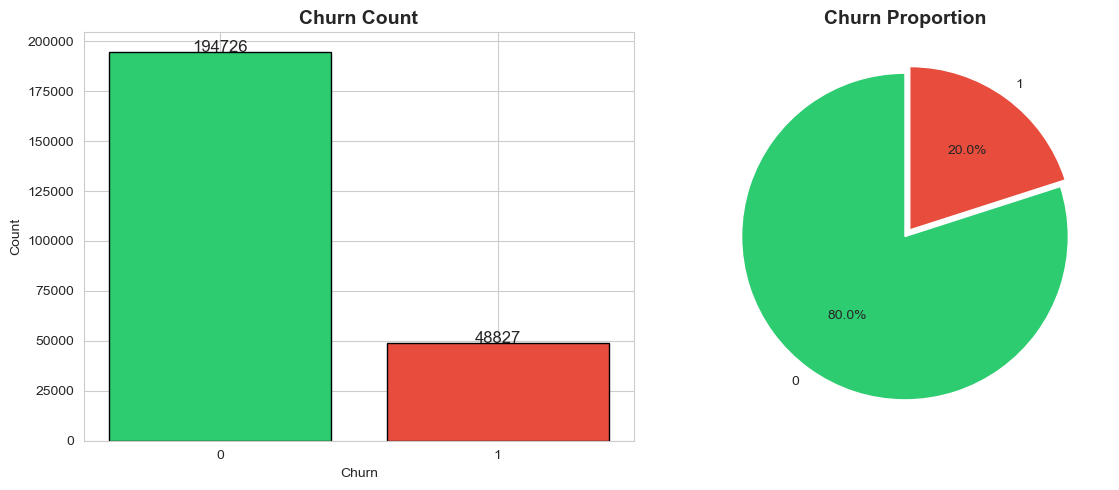

In [12]:
# ── Target: churn distribution ──
churn_counts  = df[TARGET_COL].value_counts()
churn_pct     = df[TARGET_COL].value_counts(normalize=True) * 100

# Dynamically identify churn-positive label (minority class)
churn_pos_lbl = churn_counts.idxmin()
print(f'Churn positive label detected: "{churn_pos_lbl}"')
print(pd.DataFrame({'Count': churn_counts, 'Pct%': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_colors = ['#e74c3c' if v == churn_pos_lbl else '#2ecc71'
              for v in churn_counts.index]
axes[0].bar(churn_counts.index.astype(str), churn_counts.values,
            color=bar_colors, edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=12)

pie_colors = ['#e74c3c' if v == churn_pos_lbl else '#2ecc71'
              for v in churn_counts.index]
axes[1].pie(churn_counts.values,
            labels=churn_counts.index.astype(str),
            autopct='%1.1f%%', colors=pie_colors, startangle=90,
            explode=[0.05 if v == churn_pos_lbl else 0
                     for v in churn_counts.index])
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

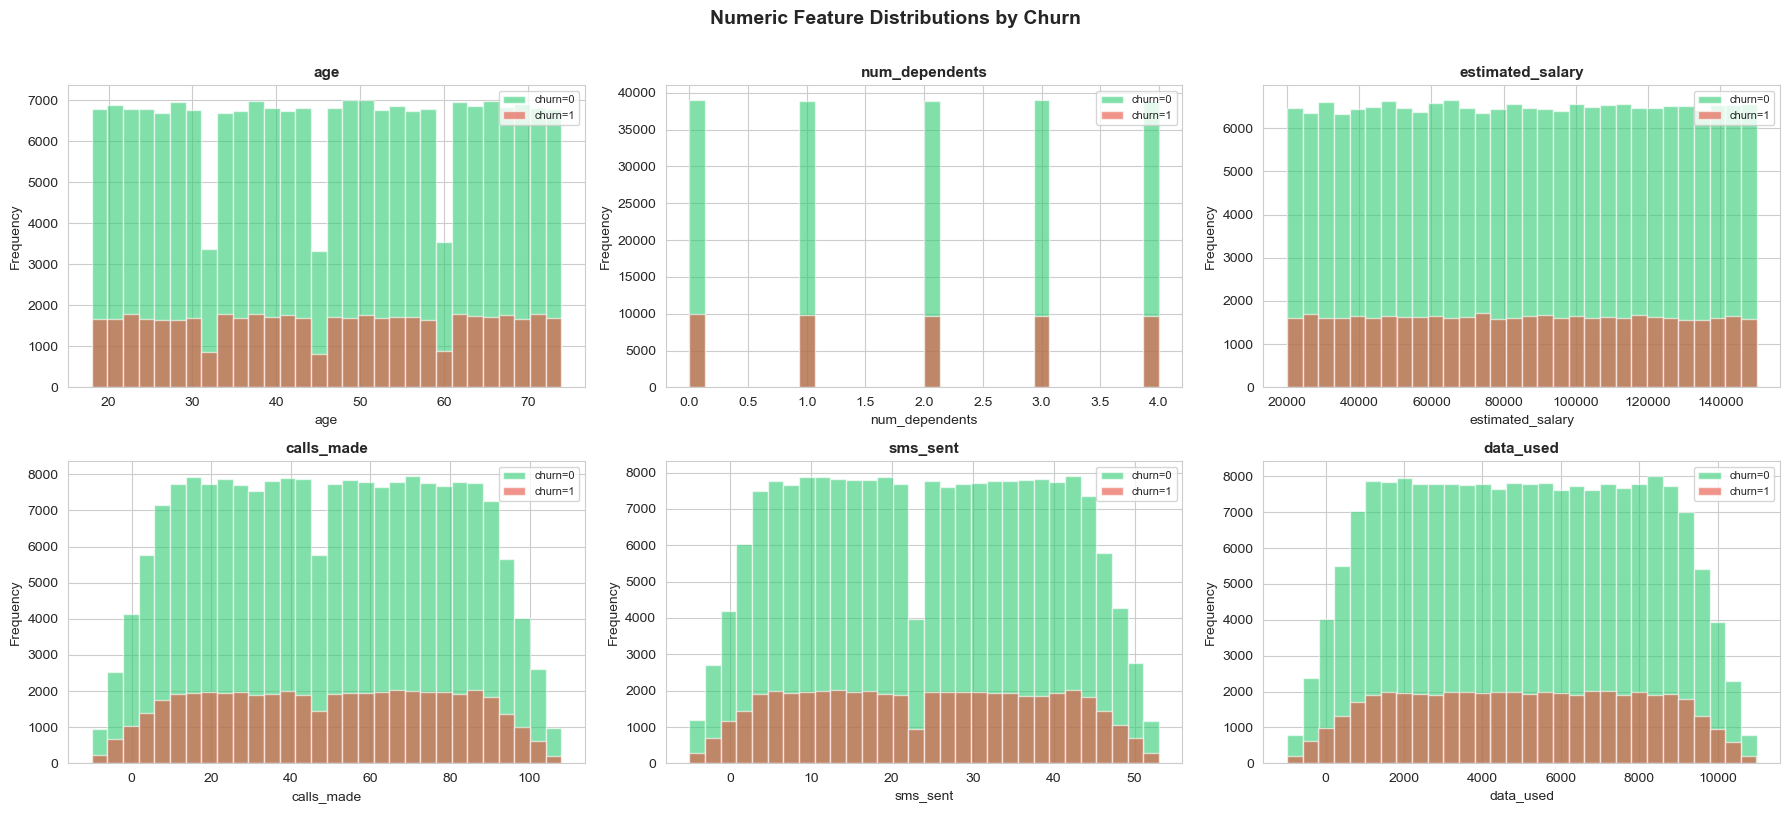

In [13]:
# ── Numeric feature distributions by churn ──
if num_cols:
    churn_labels = df[TARGET_COL].unique()
    lbl_color = {lbl: ('#e74c3c' if lbl == churn_pos_lbl else '#2ecc71')
                 for lbl in churn_labels}

    n_c = 3
    n_r = max(1, (len(num_cols) + n_c - 1) // n_c)
    fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 4))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        vals = pd.to_numeric(df[col], errors='coerce')
        for lbl in churn_labels:
            subset = vals[df[TARGET_COL] == lbl].dropna()
            axes[i].hist(subset, bins=30, alpha=0.6,
                         color=lbl_color.get(lbl, '#95a5a6'),
                         label=f'churn={lbl}', edgecolor='white')
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions by Churn',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No numeric feature columns detected.')

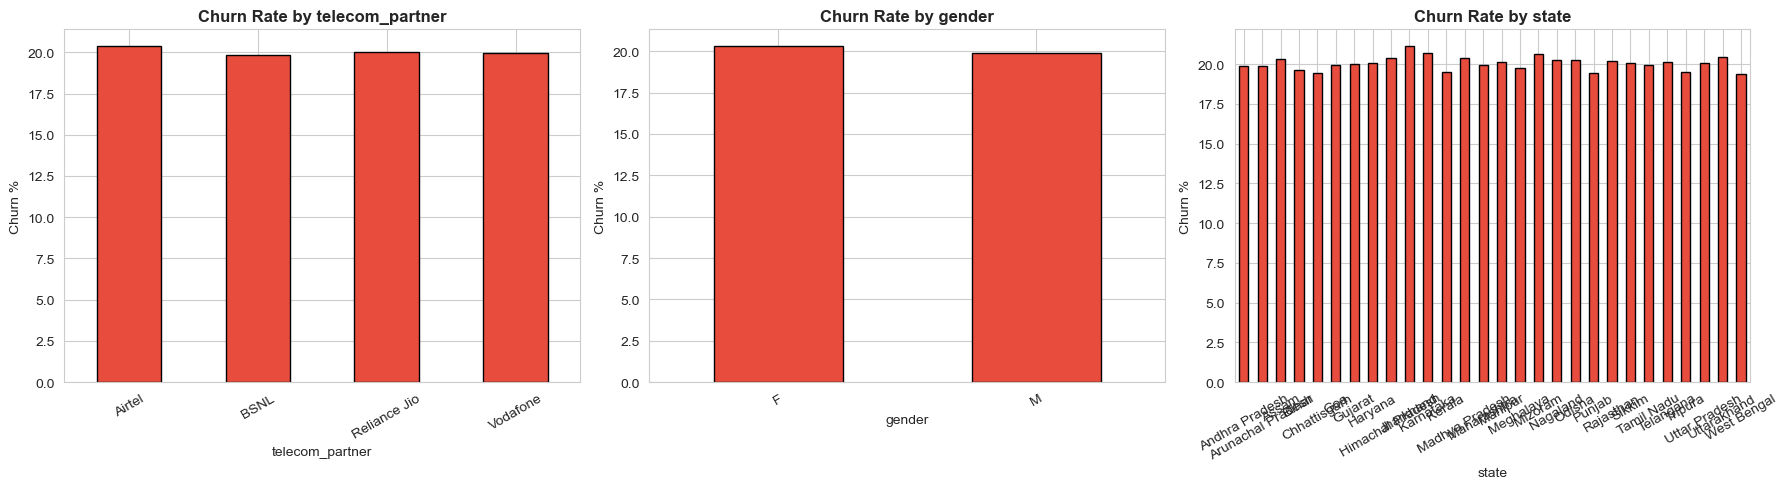

In [14]:
# ── Churn rate by categorical features ──
if cat_cols:
    n_c = min(3, len(cat_cols))
    n_r = max(1, (len(cat_cols) + n_c - 1) // n_c)
    fig, axes = plt.subplots(n_r, n_c, figsize=(6 * n_c, 5 * n_r))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        ct = df.groupby([col, TARGET_COL]).size().unstack(fill_value=0)
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        if churn_pos_lbl in ct_pct.columns:
            ct_pct[churn_pos_lbl].plot(kind='bar', ax=axes[i],
                                        color='#e74c3c', edgecolor='black')
        axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Churn %')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('churn_by_categorical.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No categorical feature columns detected.')

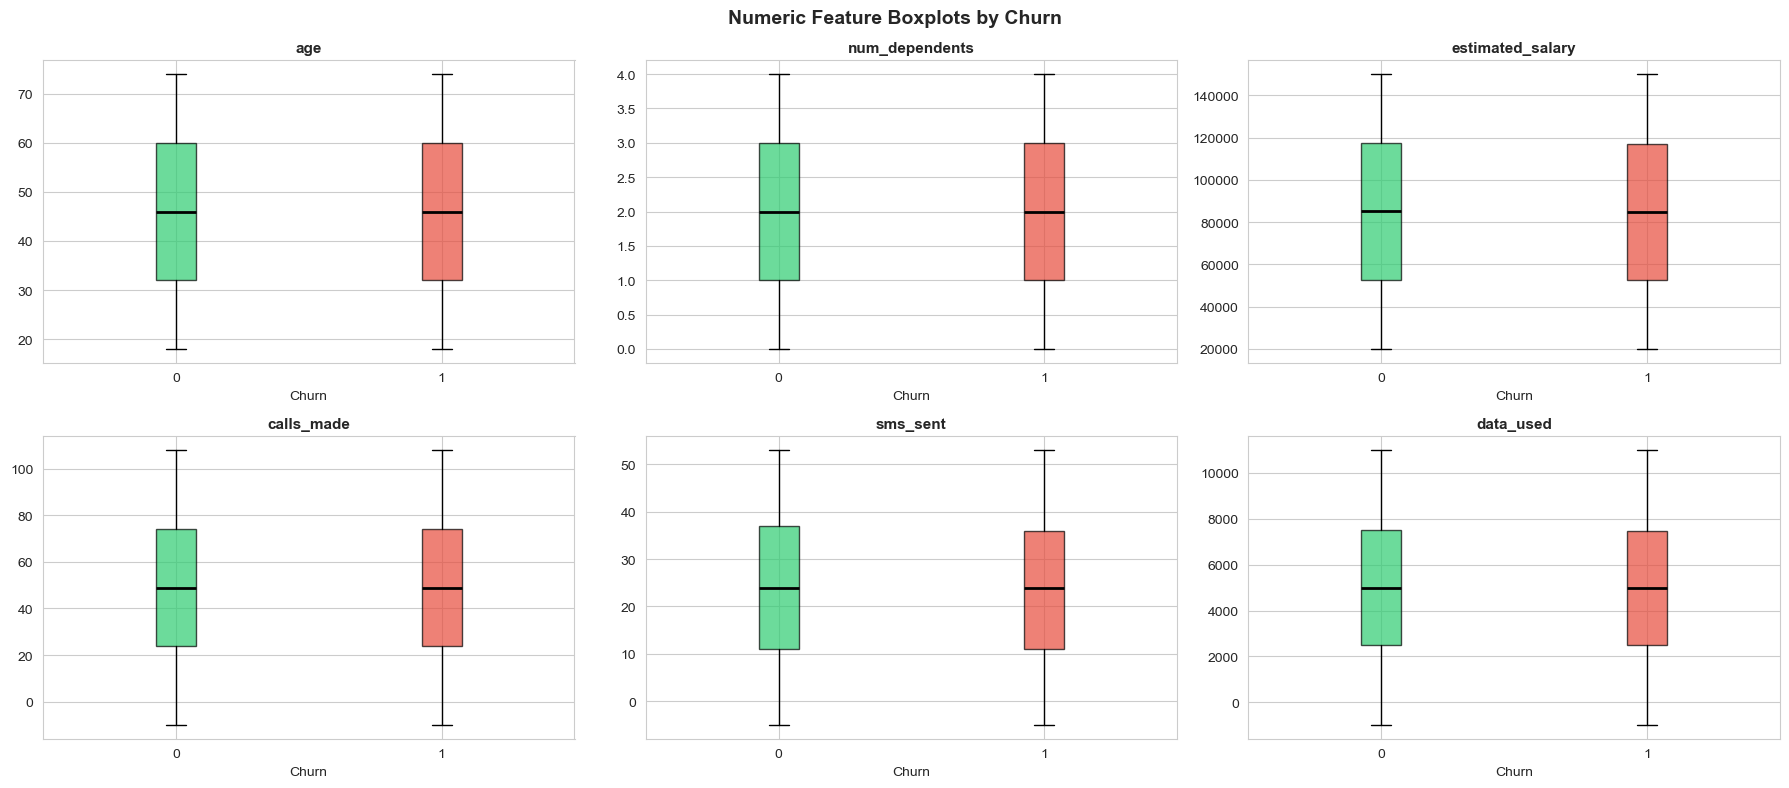

In [15]:
# ── Boxplots: numeric features vs churn ──
if num_cols:
    churn_labels = df[TARGET_COL].unique()
    n_c = 3
    n_r = max(1, (len(num_cols) + n_c - 1) // n_c)
    fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 4))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        vals = pd.to_numeric(df[col], errors='coerce')
        groups = [vals[df[TARGET_COL] == lbl].dropna().values
                  for lbl in churn_labels]
        bp = axes[i].boxplot(groups, patch_artist=True,
                              labels=[str(l) for l in churn_labels])
        colors_bp = ['#e74c3c' if lbl == churn_pos_lbl else '#2ecc71'
                     for lbl in churn_labels]
        for patch, c in zip(bp['boxes'], colors_bp):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        for med in bp['medians']:
            med.set_color('black')
            med.set_linewidth(2)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Churn')

    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Boxplots by Churn',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boxplots_by_churn.png', dpi=150, bbox_inches='tight')
    plt.show()

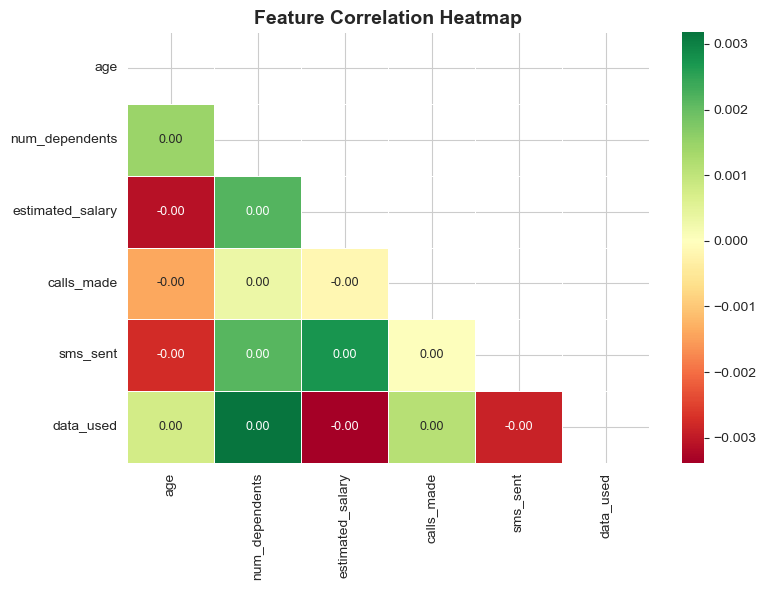

In [16]:
# ── Correlation heatmap (numeric cols only) ──
if len(num_cols) >= 2:
    num_df = df[num_cols].apply(pd.to_numeric, errors='coerce')
    corr   = num_df.corr()
    plt.figure(figsize=(max(8, len(num_cols)), max(6, len(num_cols) - 1)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')

---
## 4. Data Preprocessing

In [18]:
df_model = df.copy()

# Drop ID / irrelevant columns
drop_cols = [c for c in ID_COLS if c in df_model.columns]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)
    print('Dropped:', drop_cols)

# ── Encode target column ──
# Handles: True/False, true/false, yes/no, 1/0  — all as strings
def encode_churn(val):
    v = str(val).strip().lower()
    if v in ('true', '1', 'yes', 'churn'):
        return 1
    elif v in ('false', '0', 'no', 'no churn', 'nochurn'):
        return 0
    return np.nan

df_model[TARGET_COL] = df_model[TARGET_COL].apply(encode_churn)
before = len(df_model)
df_model.dropna(subset=[TARGET_COL], inplace=True)
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)
print(f'Rows dropped (unreadable churn value): {before - len(df_model)}')
print('Churn distribution after encoding:')
print(df_model[TARGET_COL].value_counts())

Dropped: ['customer_id', 'date_of_registration', 'pincode', 'city']
Rows dropped (unreadable churn value): 0
Churn distribution after encoding:
churn
0    194726
1     48827
Name: count, dtype: int64


In [19]:
# ── Encode remaining categorical columns ──
remaining_cat = [c for c in df_model.select_dtypes(include='object').columns
                 if c != TARGET_COL]
print('Categorical cols to encode:', remaining_cat)

le_encoders = {}
for col in remaining_cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str).str.strip())
    le_encoders[col] = le

# Convert all columns to numeric, coerce errors
for col in df_model.columns:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model.fillna(df_model.median(numeric_only=True), inplace=True)

print('\nShape after encoding:', df_model.shape)
print('Any nulls:', df_model.isnull().sum().sum())
df_model.head()

Categorical cols to encode: ['telecom_partner', 'gender', 'state']

Shape after encoding: (243553, 10)
Any nulls: 0


,telecom_partner,gender,age,state,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,2,0,25,10,4,124962,44,45,-361,0
1,2,0,55,16,2,130556,62,39,5973,0
2,3,0,57,1,0,148828,49,24,193,1
3,1,1,46,22,1,38722,80,25,9377,1
4,1,0,26,24,2,55098,78,15,1393,0


In [20]:
# ── Feature matrix and target ──
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

print('X shape:', X.shape)
print('Features:', X.columns.tolist())
print(f'Churn rate: {y.mean()*100:.2f}%')

X shape: (243553, 9)
Features: ['telecom_partner', 'gender', 'age', 'state', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']
Churn rate: 20.05%


In [21]:
# ── Train / Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train churn: {y_train.mean()*100:.2f}% | Test churn: {y_test.mean()*100:.2f}%')

Train: 194842 | Test: 48711
Train churn: 20.05% | Test churn: 20.05%


In [22]:
# ── SMOTE for class imbalance (training only) ──
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print('After SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

# ── Scaling (for Logistic Regression) ──
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done.')

After SMOTE: {0: 155780, 1: 155780}
Scaling done.


---
## 5. Model Building & Evaluation

In [24]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred)                   * 100, 2),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_te, y_pred,   zero_division=0)  * 100, 2),
        'F1 Score' : round(f1_score(y_te, y_pred,       zero_division=0)  * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba)                   * 100, 2),
    }
    return metrics, y_pred, y_proba

In [25]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_res, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression', lr, X_train_scaled, y_train_res, X_test_scaled, y_test)
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.80      0.60      0.69     38946
       Churn       0.20      0.40      0.27      9765

    accuracy                           0.56     48711
   macro avg       0.50      0.50      0.48     48711
weighted avg       0.68      0.56      0.60     48711



In [26]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
dt_res, dt_pred, dt_proba = evaluate_model(
    'Decision Tree', dt, X_train_res, y_train_res, X_test, y_test)
print('=== Decision Tree ===')
print(classification_report(y_test, dt_pred, target_names=['No Churn', 'Churn']))

=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.80      0.55      0.65     38946
       Churn       0.20      0.46      0.28      9765

    accuracy                           0.53     48711
   macro avg       0.50      0.50      0.47     48711
weighted avg       0.68      0.53      0.58     48711



In [27]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1)
rf_res, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf, X_train_res, y_train_res, X_test, y_test)
print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.80      0.67      0.73     38946
       Churn       0.21      0.34      0.25      9765

    accuracy                           0.61     48711
   macro avg       0.50      0.50      0.49     48711
weighted avg       0.68      0.61      0.64     48711



In [28]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_res, gb_pred, gb_proba = evaluate_model(
    'Gradient Boosting', gb, X_train_res, y_train_res, X_test, y_test)
print('=== Gradient Boosting ===')
print(classification_report(y_test, gb_pred, target_names=['No Churn', 'Churn']))

=== Gradient Boosting ===
              precision    recall  f1-score   support

    No Churn       0.80      0.68      0.74     38946
       Churn       0.21      0.33      0.25      9765

    accuracy                           0.61     48711
   macro avg       0.50      0.51      0.50     48711
weighted avg       0.68      0.61      0.64     48711



In [29]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, verbosity=0)
xgb_res, xgb_pred, xgb_proba = evaluate_model(
    'XGBoost', xgb, X_train_res, y_train_res, X_test, y_test)
print('=== XGBoost ===')
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

=== XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.80      0.69      0.74     38946
       Churn       0.21      0.32      0.25      9765

    accuracy                           0.62     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.62      0.64     48711



In [30]:
# Model comparison table
results_df = pd.DataFrame(
    [lr_res, dt_res, rf_res, gb_res, xgb_res]
).set_index('Model')
print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,56.16,20.25,40.41,26.98,50.55
Decision Tree,52.93,20.39,46.40,28.33,50.49
Random Forest,60.55,20.51,33.66,25.49,50.33
Gradient Boosting,61.28,20.58,32.57,25.22,50.32
XGBoost,61.65,20.54,31.84,24.97,50.23


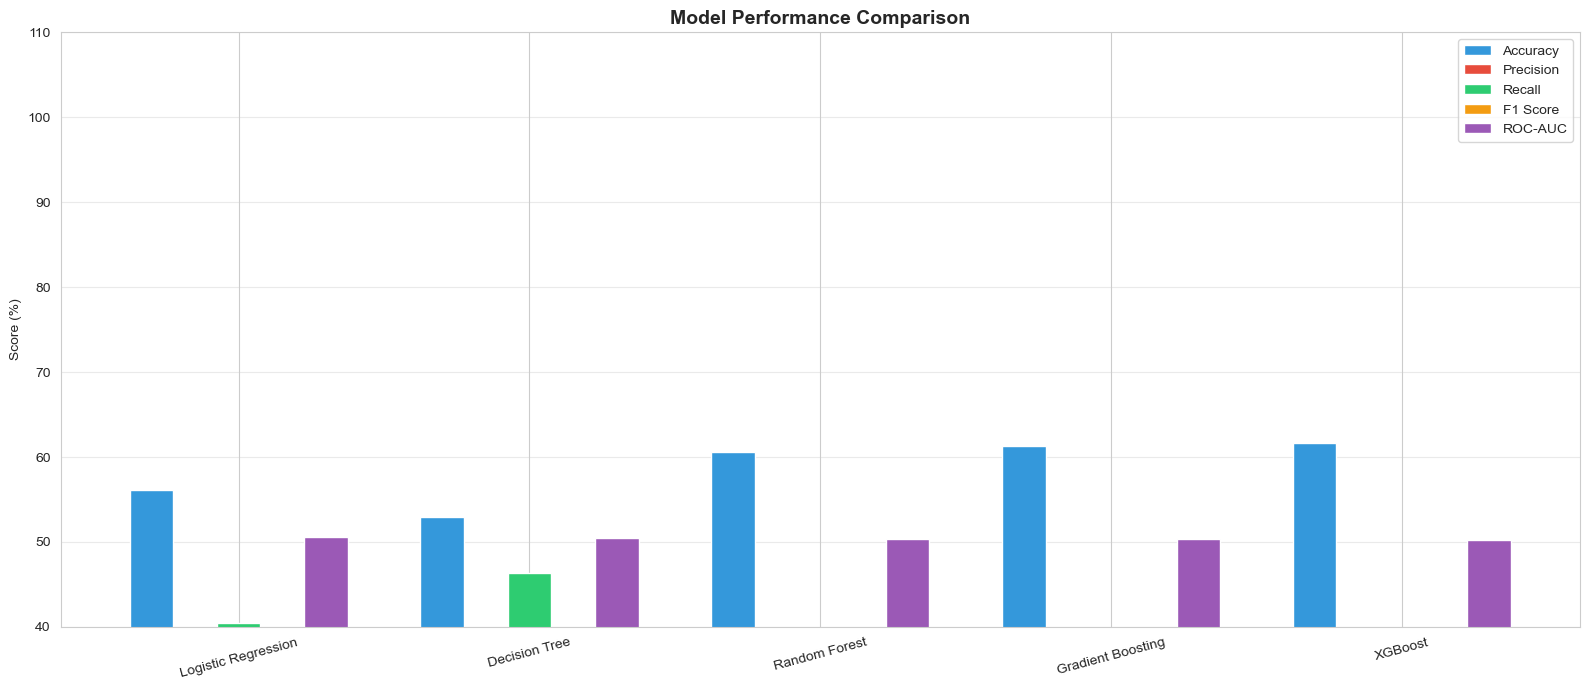

In [31]:
# Bar chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x     = np.arange(len(results_df))
width = 0.15
clrs  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (m, c) in enumerate(zip(metrics_list, clrs)):
    ax.bar(x + i * width, results_df[m], width, label=m, color=c, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(40, 110)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

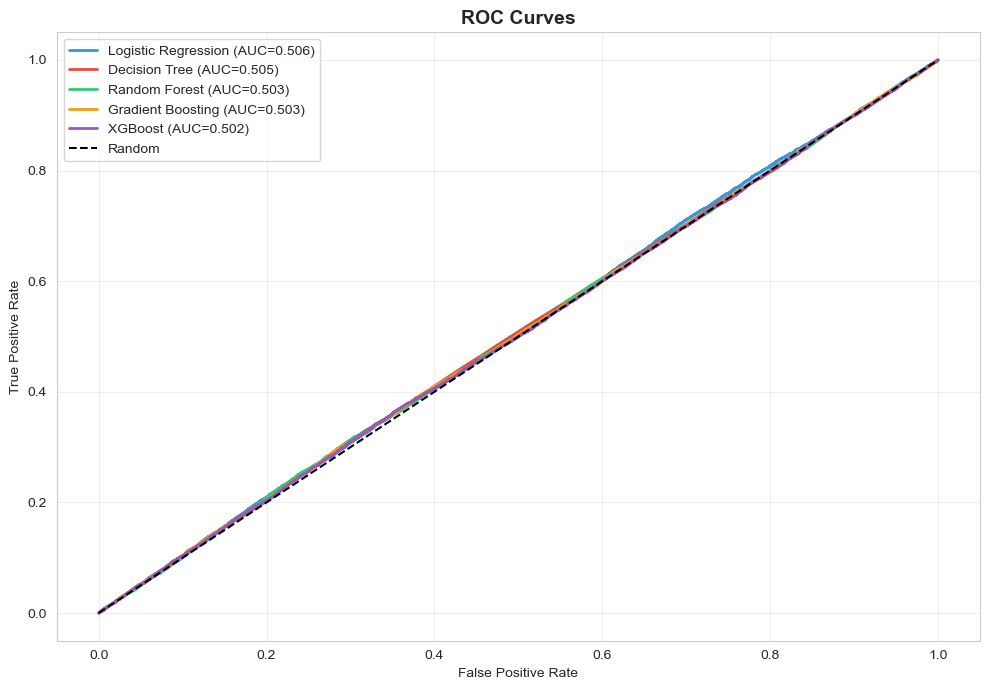

In [32]:
# ROC Curves
roc_data   = [('Logistic Regression', lr_proba), ('Decision Tree', dt_proba),
               ('Random Forest', rf_proba), ('Gradient Boosting', gb_proba),
               ('XGBoost', xgb_proba)]
roc_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 7))
for (name, proba), color in zip(roc_data, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

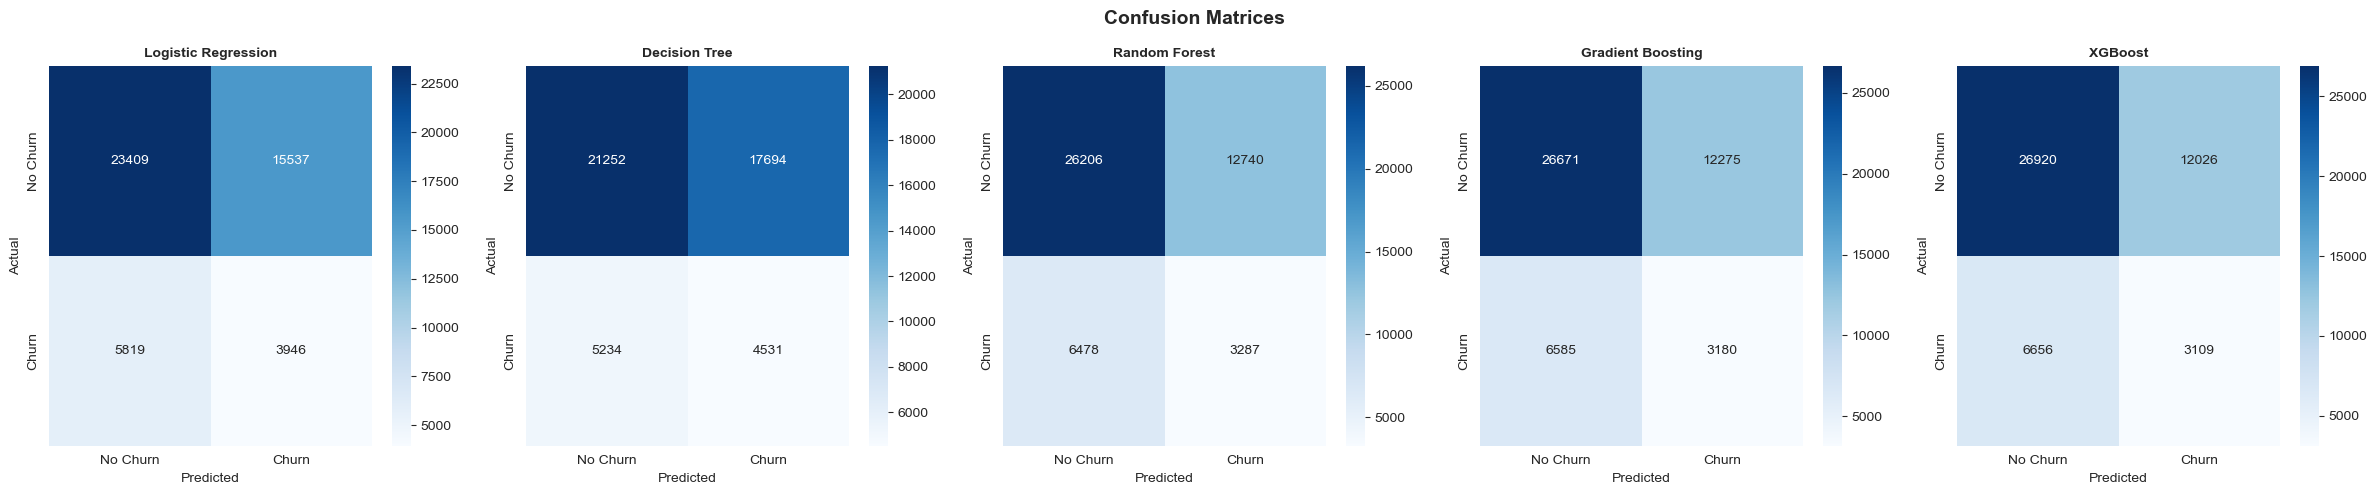

In [33]:
# Confusion Matrices
cm_data = [('Logistic Regression', lr_pred), ('Decision Tree', dt_pred),
            ('Random Forest', rf_pred), ('Gradient Boosting', gb_pred),
            ('XGBoost', xgb_pred)]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, (name, pred) in zip(axes, cm_data):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Best Model & Feature Importance (Goal 1)

In [35]:
best_name  = results_df['ROC-AUC'].idxmax()
best_score = results_df.loc[best_name, 'ROC-AUC']
print(f'Best model: {best_name}  |  ROC-AUC = {best_score}%')

Best model: Logistic Regression  |  ROC-AUC = 50.55%


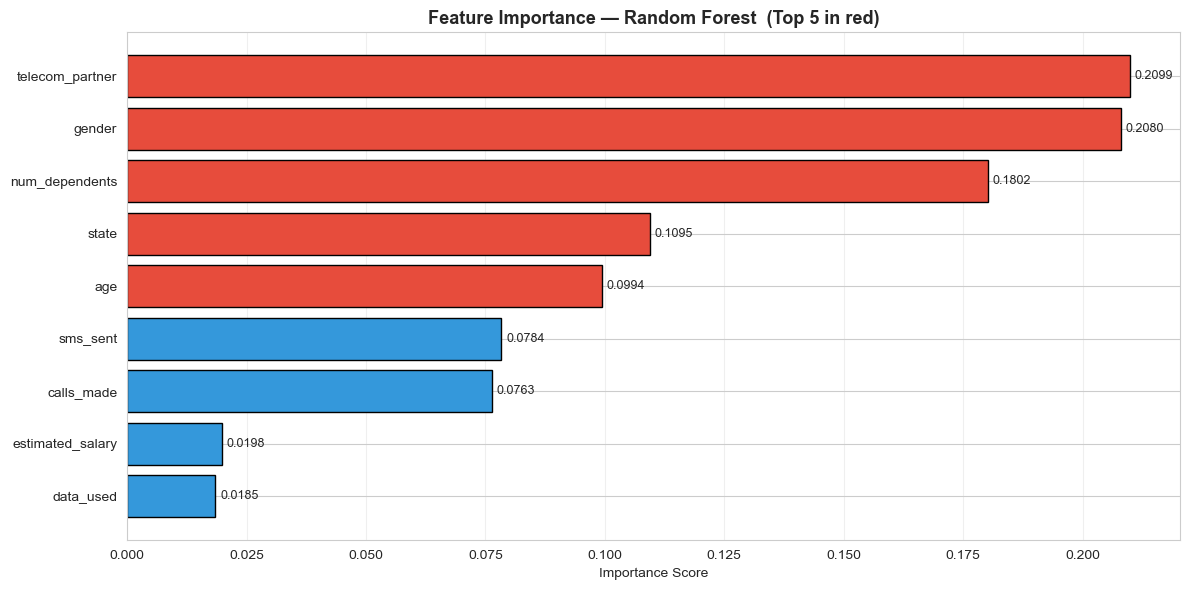

Top 5 churn drivers:
        Feature  Importance
telecom_partner    0.209885
         gender    0.208028
 num_dependents    0.180201
          state    0.109490
            age    0.099432


In [36]:
# Feature Importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, max(6, len(feat_imp) * 0.5)))
feat_colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(feat_imp))]
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=feat_colors, edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest  (Top 5 in red)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 churn drivers:')
print(feat_imp.head(5).to_string(index=False))

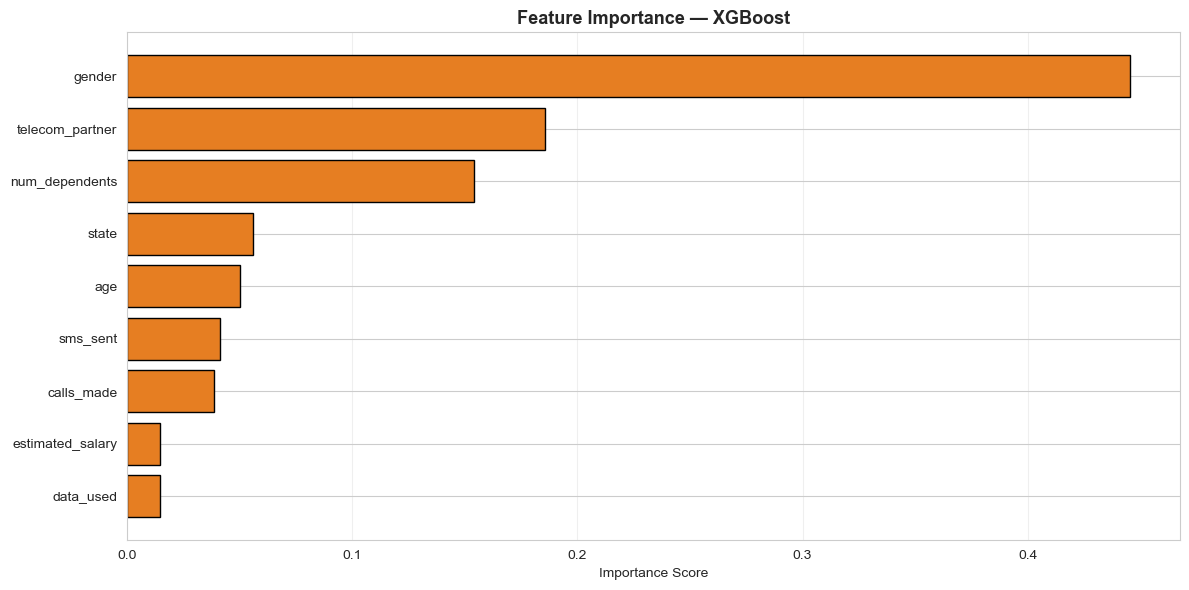

In [37]:
# Feature Importance — XGBoost
xgb_fi = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, max(6, len(xgb_fi) * 0.5)))
plt.barh(xgb_fi['Feature'], xgb_fi['Importance'],
         color='#e67e22', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Churn Risk Score Generation (Goal 2)

In [39]:
X_full = df_model.drop(columns=[TARGET_COL])

churn_risk_proba              = rf.predict_proba(X_full)[:, 1]
df_output                     = df.copy()                       # keep original readable columns
df_output['Churn_Risk_Score'] = np.round(churn_risk_proba * 100, 2)

def risk_tier(score):
    if score >= 70:   return 'High Risk'
    elif score >= 40: return 'Medium Risk'
    return 'Low Risk'

df_output['Risk_Tier'] = df_output['Churn_Risk_Score'].apply(risk_tier)

print('Risk Tier Distribution:')
print(df_output['Risk_Tier'].value_counts())
df_output[[TARGET_COL, 'Churn_Risk_Score', 'Risk_Tier']].head(10)

Risk Tier Distribution:
Risk_Tier
Low Risk       119196
Medium Risk    103274
High Risk       21083
Name: count, dtype: int64


,churn,Churn_Risk_Score,Risk_Tier
0,0,28.38,Low Risk
1,0,76.06,High Risk
2,1,37.69,Low Risk
3,1,57.15,Medium Risk
4,0,74.08,High Risk
5,0,22.82,Low Risk
6,0,76.41,High Risk
7,1,29.12,Low Risk
8,0,76.23,High Risk
9,0,75.68,High Risk


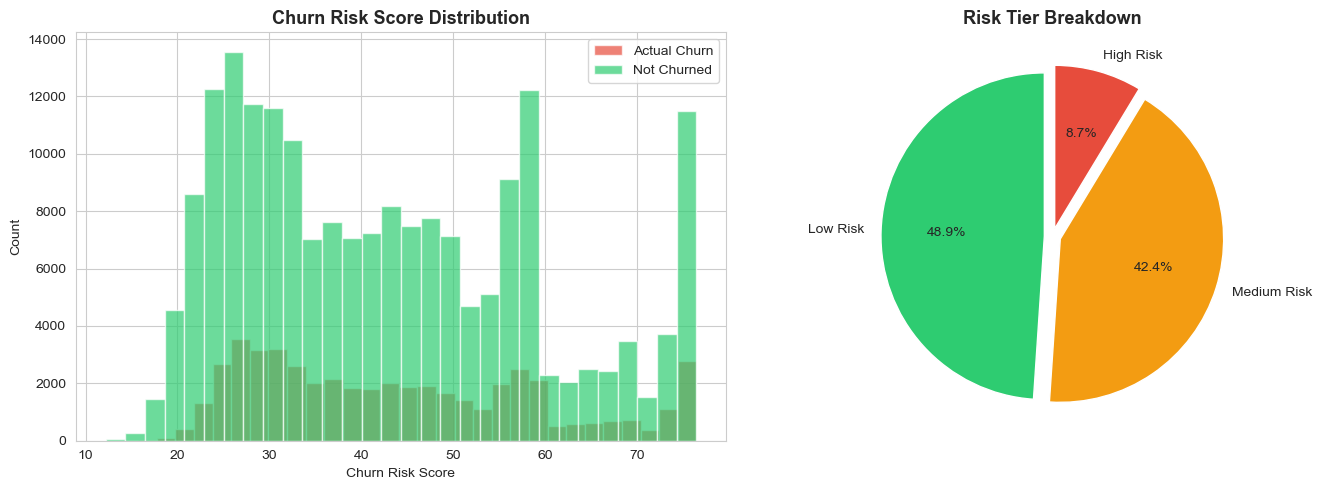

In [40]:
# Risk score distribution chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask_yes = df_output[TARGET_COL] == churn_pos_lbl
axes[0].hist(df_output[mask_yes]['Churn_Risk_Score'],
             bins=30, alpha=0.7, color='#e74c3c', label='Actual Churn')
axes[0].hist(df_output[~mask_yes]['Churn_Risk_Score'],
             bins=30, alpha=0.7, color='#2ecc71', label='Not Churned')
axes[0].set_xlabel('Churn Risk Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn Risk Score Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

tier_counts  = df_output['Risk_Tier'].value_counts()
tc_colors    = {'High Risk':'#e74c3c','Medium Risk':'#f39c12','Low Risk':'#2ecc71'}
axes[1].pie(tier_counts.values, labels=tier_counts.index,
            autopct='%1.1f%%',
            colors=[tc_colors[t] for t in tier_counts.index],
            startangle=90, explode=[0.05]*len(tier_counts))
axes[1].set_title('Risk Tier Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. CHURN-FLAG Prediction (Goal 3)

In [42]:
df_output['CHURN_FLAG']       = rf.predict(X_full)          # 0 or 1
df_output['CHURN_FLAG_LABEL'] = df_output['CHURN_FLAG'].map({1:'YES', 0:'NO'})

print('CHURN-FLAG Distribution:')
print(df_output['CHURN_FLAG_LABEL'].value_counts())

# Customers for email campaign
show_cols = [c for c in ['customer_id', TARGET_COL, 'telecom_partner',
                          'Churn_Risk_Score', 'Risk_Tier', 'CHURN_FLAG_LABEL']
             if c in df_output.columns]
email_targets = (
    df_output[df_output['CHURN_FLAG'] == 1][show_cols]
    .sort_values('Churn_Risk_Score', ascending=False)
)
print(f'Customers flagged for email campaign: {len(email_targets)}')
email_targets.head(10)

CHURN-FLAG Distribution:
CHURN_FLAG_LABEL
NO     163596
YES     79957
Name: count, dtype: int64
Customers flagged for email campaign: 79957


,customer_id,churn,telecom_partner,Churn_Risk_Score,Risk_Tier,CHURN_FLAG_LABEL
155025,155026,0,BSNL,76.48,High Risk,YES
145271,145272,0,BSNL,76.48,High Risk,YES
156046,156047,1,BSNL,76.48,High Risk,YES
202757,202758,0,BSNL,76.48,High Risk,YES
68273,68274,0,BSNL,76.48,High Risk,YES
13260,13261,0,BSNL,76.48,High Risk,YES
67735,67736,1,BSNL,76.48,High Risk,YES
189104,189105,0,BSNL,76.48,High Risk,YES
99309,99310,1,BSNL,76.46,High Risk,YES
240820,240821,0,BSNL,76.46,High Risk,YES


In [43]:
# Save final output CSV
save_cols = [c for c in
             list(df.columns) + ['Churn_Risk_Score', 'Risk_Tier', 'CHURN_FLAG', 'CHURN_FLAG_LABEL']
             if c in df_output.columns]
df_output[save_cols].to_csv('telecom_churn_predictions.csv', index=False)
print(f'Saved {len(df_output)} rows  ->  telecom_churn_predictions.csv')
df_output[save_cols].head(10)

Saved 243553 rows  ->  telecom_churn_predictions.csv


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,Churn_Risk_Score,Risk_Tier,CHURN_FLAG,CHURN_FLAG_LABEL
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0,28.38,Low Risk,0,NO
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0,76.06,High Risk,1,YES
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1,37.69,Low Risk,0,NO
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1,57.15,Medium Risk,1,YES
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0,74.08,High Risk,1,YES
5,6,Vodafone,M,36,Uttarakhand,Chennai,120612,2020-01-01,1,73452,91,24,8109,0,22.82,Low Risk,0,NO
6,7,BSNL,F,60,Karnataka,Delhi,609616,2020-01-01,1,110035,36,13,8512,0,76.41,High Risk,1,YES
7,8,BSNL,M,46,Arunachal Pradesh,Kolkata,866786,2020-01-01,4,104541,87,40,2245,1,29.12,Low Risk,0,NO
8,9,Reliance Jio,F,53,Himachal Pradesh,Mumbai,765257,2020-01-01,2,79439,34,12,10039,0,76.23,High Risk,1,YES
9,10,BSNL,F,57,Rajasthan,Mumbai,506308,2020-01-01,0,126422,61,33,567,0,75.68,High Risk,1,YES


---
## 9. Cross-Validation — Robustness Check

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0),
}

cv_results = {}
for name, model in cv_models.items():
    tr_X = X_train_scaled if name == 'Logistic Regression' else X_train_res
    scores = cross_val_score(model, tr_X, y_train_res,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25}  Mean AUC = {scores.mean():.4f}  +/-  {scores.std():.4f}')

Logistic Regression        Mean AUC = 0.6462  +/-  0.0018
Random Forest              Mean AUC = 0.7300  +/-  0.0019
XGBoost                    Mean AUC = 0.7447  +/-  0.0016


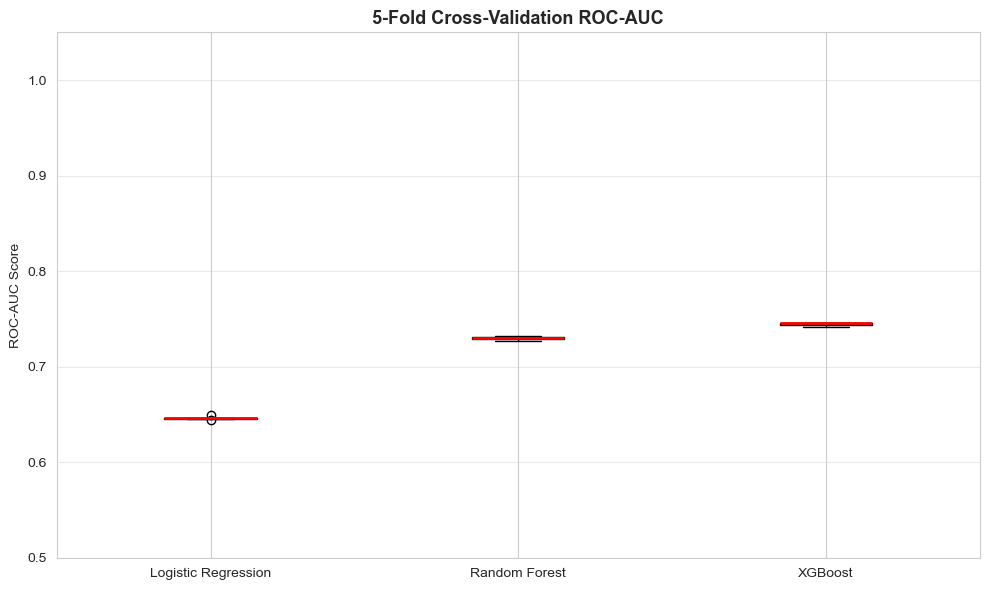

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(list(cv_results.values()),
           labels=list(cv_results.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='black'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('5-Fold Cross-Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Business Insights & Recommendations

In [48]:
sep = '=' * 65
print(sep)
print('    BUSINESS INSIGHTS — No-Churn Telecom (PM-PR-0017)')
print(sep)

print('\nGOAL 1 — Top Churn Drivers (Random Forest):')
print('-' * 50)
for rank, row in feat_imp.head(5).iterrows():
    print(f"  {rank+1}. {row['Feature']:<25}  Score: {row['Importance']:.4f}")

print('\nGOAL 2 — Churn Risk Score Summary:')
print('-' * 50)
tier_summary = (
    df_output.groupby('Risk_Tier')['Churn_Risk_Score']
    .agg(['count','mean','min','max'])
    .rename(columns={'count':'Customers','mean':'Avg','min':'Min','max':'Max'})
    .round(2)
)
print(tier_summary.to_string())

print('\nGOAL 3 — CHURN-FLAG Campaign Targeting:')
print('-' * 50)
total    = len(df_output)
flag_yes = int((df_output['CHURN_FLAG'] == 1).sum())
flag_no  = total - flag_yes
print(f'  Total customers      : {total}')
print(f'  CHURN-FLAG = YES (1) : {flag_yes} ({flag_yes/total*100:.1f}%)  <- EMAIL CAMPAIGN')
print(f'  CHURN-FLAG = NO  (0) : {flag_no} ({flag_no/total*100:.1f}%)')

print('\nMODEL PERFORMANCE:')
print('-' * 50)
print(results_df.to_string())

print('\nKEY RECOMMENDATIONS:')
print('-' * 50)
recs = [
    'Focus retention campaigns on top feature drivers identified above.',
    'Customers with Risk Score >= 70 (High Risk) need human outreach, not just emails.',
    'Automate email campaigns targeting all CHURN-FLAG = YES customers.',
    'Re-run the model monthly to refresh scores as customer behaviour evolves.',
    'Investigate customer service interaction patterns for early churn signals.',
]
for i, r in enumerate(recs, 1):
    print(f'  {i}. {r}')
print(sep)

    BUSINESS INSIGHTS — No-Churn Telecom (PM-PR-0017)

GOAL 1 — Top Churn Drivers (Random Forest):
--------------------------------------------------
  1. telecom_partner            Score: 0.2099
  2. gender                     Score: 0.2080
  3. num_dependents             Score: 0.1802
  4. state                      Score: 0.1095
  5. age                        Score: 0.0994

GOAL 2 — Churn Risk Score Summary:
--------------------------------------------------
             Customers    Avg    Min    Max
Risk_Tier                                  
High Risk        21083  74.70  70.00  76.48
Low Risk        119196  29.16  12.17  39.99
Medium Risk     103274  52.46  40.00  69.99

GOAL 3 — CHURN-FLAG Campaign Targeting:
--------------------------------------------------
  Total customers      : 243553
  CHURN-FLAG = YES (1) : 79957 (32.8%)  <- EMAIL CAMPAIGN
  CHURN-FLAG = NO  (0) : 163596 (67.2%)

MODEL PERFORMANCE:
--------------------------------------------------
                    

---
## Summary

| Goal | Deliverable | Status |
|------|-------------|--------|
| 1. Understand churn drivers | Feature Importance — RF + XGBoost | Done |
| 2. Churn Risk Scores (0-100) | `Churn_Risk_Score` + `Risk_Tier` | Done |
| 3. CHURN-FLAG variable | `CHURN_FLAG` (0/1) + `CHURN_FLAG_LABEL` (YES/NO) | Done |

**Output file:** `telecom_churn_predictions.csv`